#Tarea Unidad 2
## Milena Fernanda Rivera Hernández

El dataset propuesto consiste de 49 muestras para cinco subtipos de cáncer de mama, provenientes de datos de RNA-seq.

El objetivo es identificar un conjunto de genes para cada uno de los subtipos de cáncer de mama e identificar si existen funciones celulares enriquecidas.


El conjunto de datos tiene identificadores de la pagina:

https://www.ensembl.org/Homo_sapiens/Tools/IDMapper

Este es un ejemplo: ENSG00000000003.10

El valor .10 se refiere a la versión de secuenciación del que proviene, por favor eliminen esa parte del ID, les debería quedar ENSG00000000003


Con el archivo que agrego pueden realizar el reemplazo de los ID de ensembl a gene name, para que puedan realizar la anotación de funciones. Puede ocurrir que algunos ensembl no tengan un gene name.

In [55]:
# NOTA IMPORTANTE: Los archivos se importaron desde colab sample_data por lo que
# si se desea replicar o correr el programa desde su sesion se debe realizar
# la respectiva importacion

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.decomposition import NMF
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, cophenet

In [7]:
dataset = pd.read_csv('/content/genes150621sincontrol.txt',sep='\t')

# arreglamos lo de la versión de secuenciación del que proviene
dataset['gene_id'] = dataset['gene_id'].str.split('.').str[0]

# Definimos los indices
dataset = dataset.set_index('gene_id')

dataset.head()

,AU565_BREAST,BT20_BREAST,BT474_BREAST,BT483_BREAST,BT549_BREAST,CAL120_BREAST,CAL148_BREAST,CAL51_BREAST,CAL851_BREAST,CAMA1_BREAST,...,MDAMB415_BREAST,MDAMB436_BREAST,MDAMB453_BREAST,MDAMB468_BREAST,SKBR3_BREAST,T47D_BREAST,UACC812_BREAST,UACC893_BREAST,ZR751_BREAST,ZR7530_BREAST
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,16.33,14.81,5.88,16.41,15.66,32.21,25.17,86.37,48.36,3.75,...,17.44,10.15,0.27,47.91,7.63,14.93,7.19,22.62,8.12,16.81
ENSG00000000005,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.12,0.00,0.00,0.00,0.00,0.00,0.00
ENSG00000000419,107.48,127.27,162.93,86.38,133.55,122.41,59.36,79.09,49.79,62.82,...,75.38,77.34,58.23,117.68,128.17,106.38,203.21,67.63,139.23,56.20
ENSG00000000457,10.32,6.65,15.37,12.03,3.59,1.93,7.63,8.79,2.42,9.46,...,3.00,6.57,12.99,7.79,8.82,5.42,3.65,18.09,15.96,13.76
ENSG00000000460,18.91,15.02,23.64,8.49,16.91,9.32,20.62,15.71,9.82,13.80,...,4.16,21.95,14.90,25.16,13.94,16.14,4.94,20.61,17.45,11.53


In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43214 entries, ENSG00000000003 to ENSG00000252065
Data columns (total 49 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   AU565_BREAST        43214 non-null  float64
 1   BT20_BREAST         43214 non-null  float64
 2   BT474_BREAST        43214 non-null  float64
 3   BT483_BREAST        43214 non-null  float64
 4   BT549_BREAST        43214 non-null  float64
 5   CAL120_BREAST       43214 non-null  float64
 6   CAL148_BREAST       43214 non-null  float64
 7   CAL51_BREAST        43214 non-null  float64
 8   CAL851_BREAST       43214 non-null  float64
 9   CAMA1_BREAST        43214 non-null  float64
 10  DU4475_BREAST       43214 non-null  float64
 11  EFM192A_BREAST      43214 non-null  float64
 12  EFM19_BREAST        43214 non-null  float64
 13  HCC1143_BREAST      43214 non-null  float64
 14  HCC1187_BREAST      43214 non-null  float64
 15  HCC1419_BREAST      43214 non-null

In [9]:
# Filtramos los datos porque son muchisimos
# Calcular varianza por gen
gene_variance = dataset.var(axis=1)

# Conservar top 10,000 genes mas variables
top_genes = gene_variance.nlargest(10000).index
filtered_expr = dataset.loc[top_genes]

print(f"Top 10k genes mas variables: {filtered_expr.shape}")
filtered_expr.head()

Top 10k genes mas variables: (10000, 49)


,AU565_BREAST,BT20_BREAST,BT474_BREAST,BT483_BREAST,BT549_BREAST,CAL120_BREAST,CAL148_BREAST,CAL51_BREAST,CAL851_BREAST,CAMA1_BREAST,...,MDAMB415_BREAST,MDAMB436_BREAST,MDAMB453_BREAST,MDAMB468_BREAST,SKBR3_BREAST,T47D_BREAST,UACC812_BREAST,UACC893_BREAST,ZR751_BREAST,ZR7530_BREAST
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000228253,43830.0,53693.0,74771.0,81741.0,42111.0,26053.0,46339.0,65465.0,124630.0,75162.0,...,76228.0,41794.0,84325.0,57544.0,57463.0,101940.0,107170.0,83254.0,21171.0,71072.0
ENSG00000198712,18094.0,29051.0,34778.0,29581.0,15159.0,9622.4,24371.0,17610.0,62217.0,28946.0,...,26853.0,20046.0,26414.0,29470.0,23596.0,26737.0,36479.0,39411.0,11957.0,23351.0
ENSG00000198804,15890.0,20117.0,19804.0,27748.0,13622.0,11519.0,15426.0,20839.0,47116.0,21651.0,...,37479.0,14912.0,16348.0,18294.0,23117.0,13608.0,41103.0,19598.0,9788.8,18512.0
ENSG00000198938,5577.8,17270.0,25851.0,21324.0,11636.0,7519.9,21953.0,20021.0,46826.0,22655.0,...,35516.0,13645.0,16786.0,17761.0,9496.2,19485.0,37372.0,27414.0,8031.0,18185.0
ENSG00000210082,3015.1,6269.1,10175.0,7287.2,9203.8,5832.0,4422.9,7549.4,18811.0,5943.1,...,13200.0,5524.3,3977.2,5733.0,1954.6,2104.3,4916.9,16723.0,4773.9,7875.6


Text(0, 0.5, 'Expression')

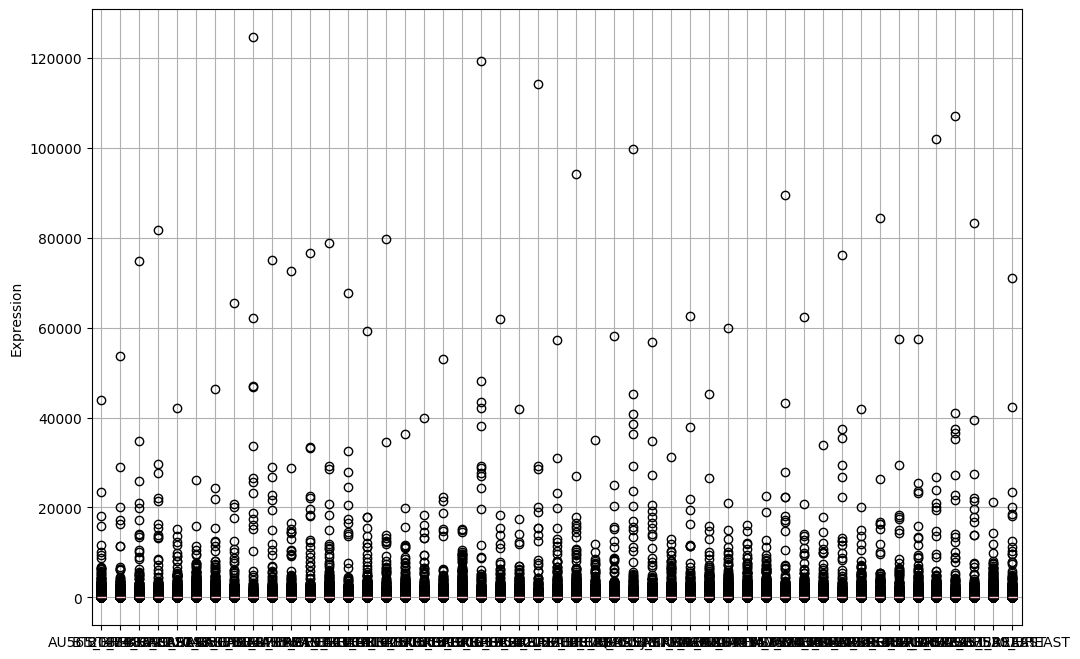

In [10]:
fig, axes = plt.subplots(figsize=(12,8))
ax = dataset.boxplot(color='pink')
ax.set_ylabel('Expression')

Text(0, 0.5, 'Expression filtrada')

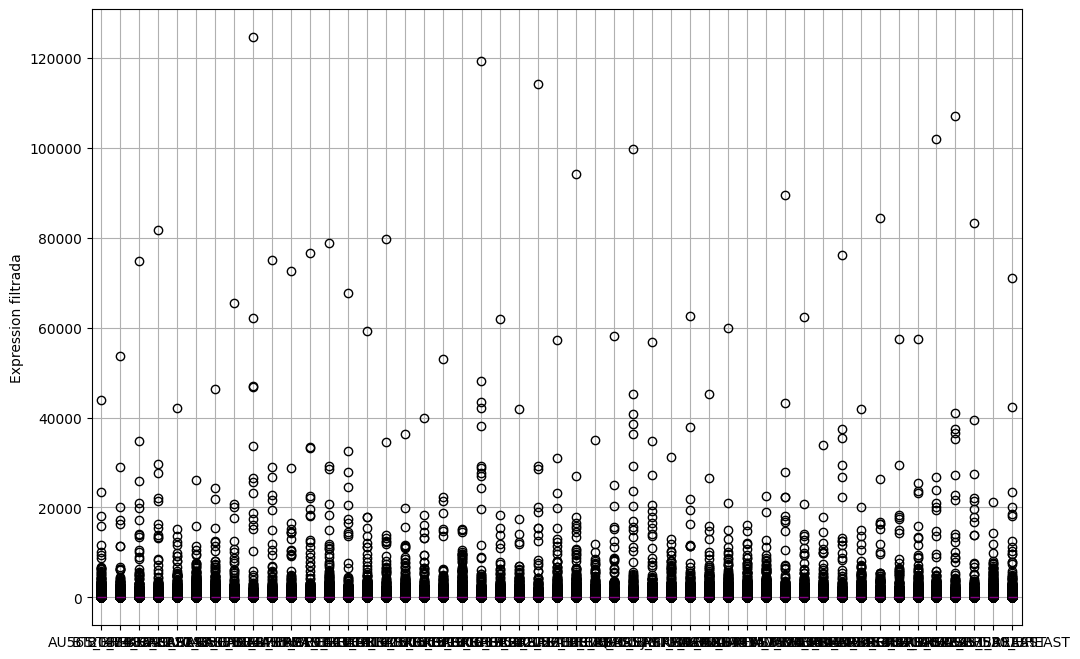

In [11]:
fig, axes = plt.subplots(figsize=(12,8))
ax = filtered_expr.boxplot(color='purple')
ax.set_ylabel('Expression filtrada')

/usr/local/lib/python3.11/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)


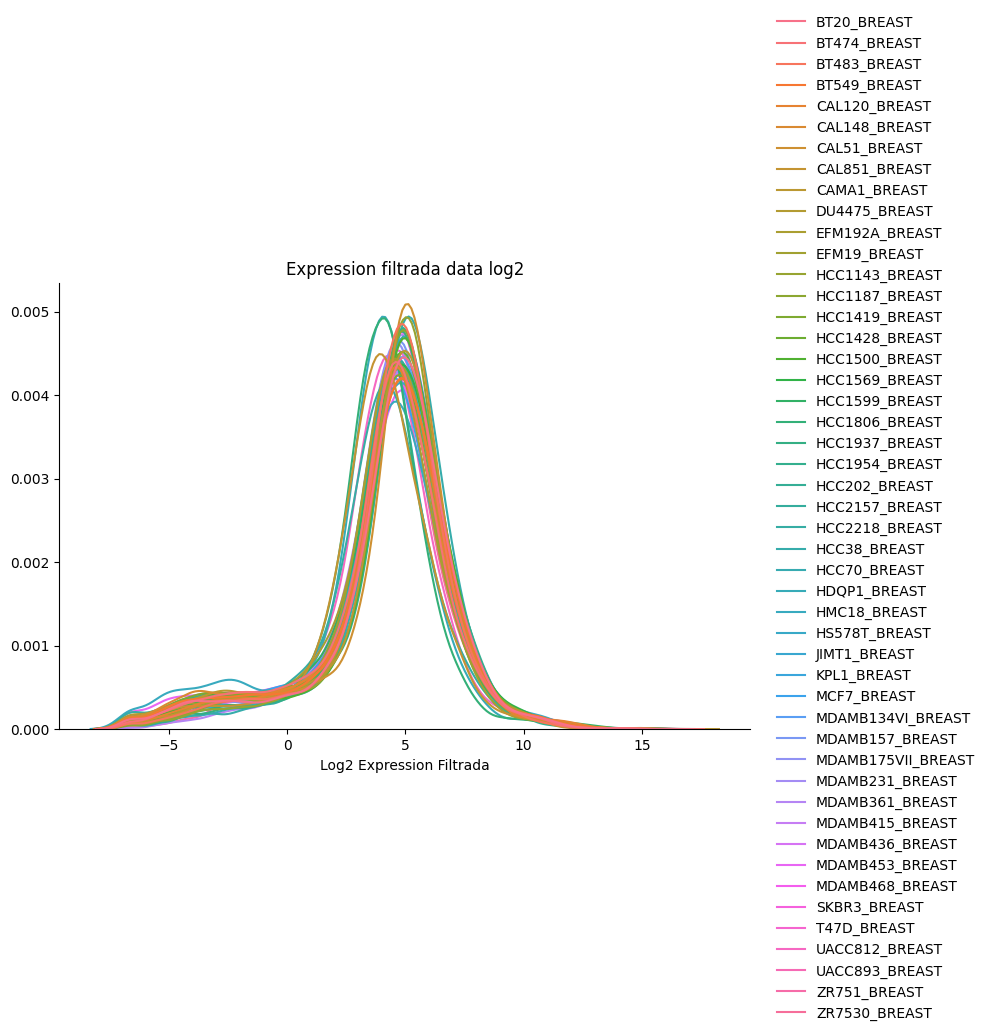

In [12]:
log_expression=np.log2(filtered_expr.iloc[:,1:])
fig=sns.displot(log_expression,  kind='kde', height=5, aspect=1.6)
plt.title("Expression filtrada data log2")
fig.set_axis_labels('Log2 Expression Filtrada', '')

Text(0, 0.5, 'Log2 Expression')

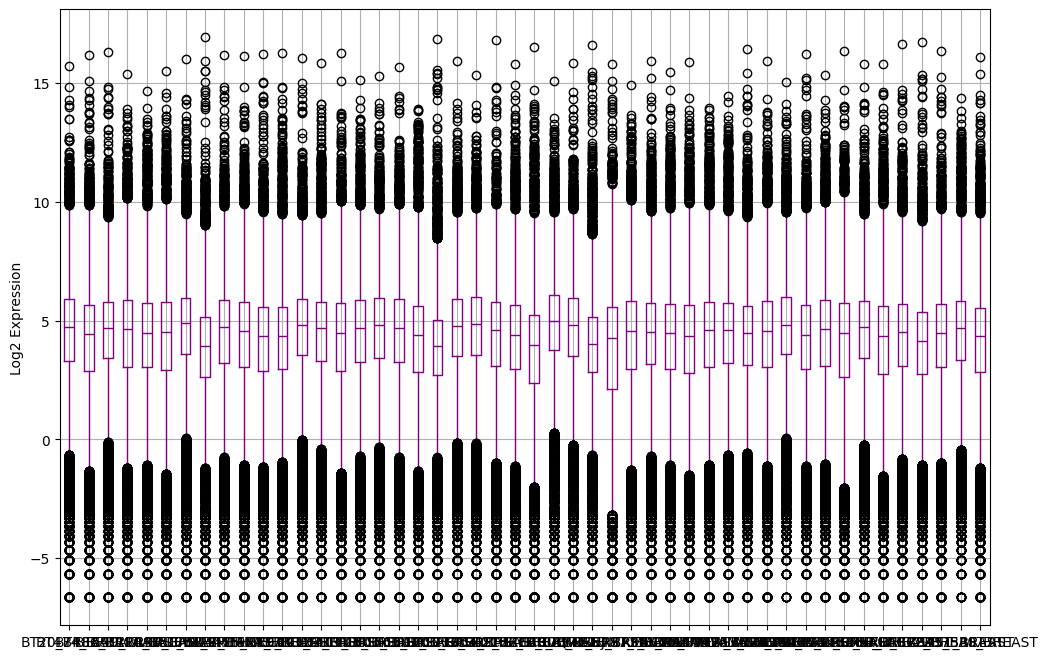

In [13]:
fig, axes = plt.subplots(figsize=(12,8))
ax = log_expression.boxplot(color='purple')
ax.set_ylabel('Log2 Expression')

In [14]:
# Normalizacion
def quantileNormalize(input):
    temp = input.copy()
    #compute rank
    dic = {}
    for col in temp:
        dic.update({col : sorted(temp[col])})
    sorted_df = pd.DataFrame(dic)
    rank = sorted_df.mean(axis = 1).tolist()
    #sort
    for col in temp:
        t = np.searchsorted(np.sort(temp[col]), temp[col])
        temp[col] = [rank[i] for i in t]
    return temp
Norm_samples=quantileNormalize(dataset.iloc[:,1:])
print(Norm_samples)


# filtradas por varianza
Norm_samples_filtered=quantileNormalize(filtered_expr.iloc[:,1:])
print(Norm_samples_filtered)


                 BT20_BREAST  BT474_BREAST  BT483_BREAST  BT549_BREAST  \
gene_id                                                                  
ENSG00000000003    12.994167      6.961667     14.661042     15.127708   
ENSG00000000005     0.000000      0.000000      0.000000      0.000000   
ENSG00000000419   111.405833    168.594167     85.644167    117.461250   
ENSG00000000457     5.963542     16.959792     10.488750      4.074792   
ENSG00000000460    13.213958     25.643542      7.240000     16.345000   
...                      ...           ...           ...           ...   
ENSG00000252061     0.000000      0.000000      0.000000      0.000000   
ENSG00000252062     0.000000      0.000000      0.000000      0.000000   
ENSG00000252063     0.000000      0.000000      0.000000      0.000000   
ENSG00000252064     0.000000      0.000000      0.000000      0.000000   
ENSG00000252065     0.000000      0.000000      0.000000      0.000000   

                 CAL120_BREAST  CAL14

/usr/local/lib/python3.11/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)


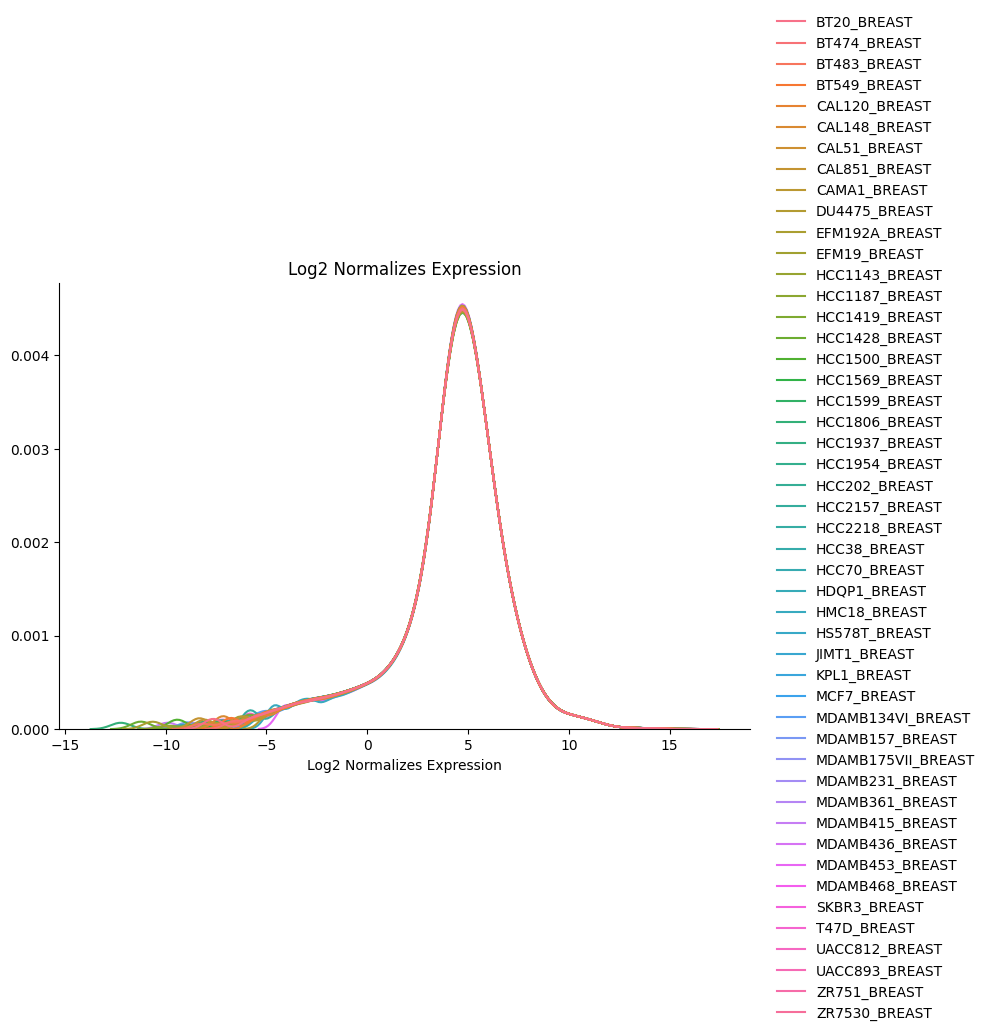

In [15]:
log_norm_expression = np.log2(Norm_samples_filtered)
fig=sns.displot(log_norm_expression,  kind='kde', height=5, aspect=1.6)
plt.title("Log2 Normalizes Expression")
fig.set_axis_labels('Log2 Normalizes Expression', '')

In [16]:
# Generalmente ponemos las caracteristicas como columnas y las instancias como
# filas. Por lo tanto realizaremos la transpuesta de nuestro dataset.
expression_transpose = log_norm_expression.T
expression_transpose.info()
expression_transpose.head()

<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, BT20_BREAST to ZR7530_BREAST
Columns: 10000 entries, ENSG00000228253 to ENSG00000188493
dtypes: float64(10000)
memory usage: 3.7+ MB


gene_id,ENSG00000228253,ENSG00000198712,ENSG00000198804,ENSG00000198938,ENSG00000210082,ENSG00000110484,ENSG00000198899,ENSG00000108298,ENSG00000212907,ENSG00000198840,...,ENSG00000228205,ENSG00000225548,ENSG00000215115,ENSG00000002016,ENSG00000103966,ENSG00000125843,ENSG00000163864,ENSG00000101752,ENSG00000090432,ENSG00000188493
BT20_BREAST,15.94736,14.744499,14.402414,14.193384,13.329139,-4.004817,14.041144,10.181580,13.829207,13.196400,...,2.043155,3.065371,-inf,2.898087,3.947647,4.099155,-3.643856,2.941302,4.231285,3.323460
BT474_BREAST,15.94736,14.744499,14.041144,14.402414,13.002000,6.709239,13.829207,14.193384,13.507807,13.658493,...,3.984532,-inf,-inf,3.645947,4.345021,3.676639,1.562649,3.888764,4.116500,2.776192
BT483_BREAST,15.94736,14.744499,14.402414,14.041144,12.724842,2.095292,14.193384,10.509101,13.658493,13.829207,...,1.963320,-inf,-inf,3.097049,4.198772,4.044922,1.534601,3.285865,3.772458,1.908172
BT549_BREAST,15.94736,14.744499,14.402414,14.041144,13.507807,-0.465191,14.193384,10.265832,13.829207,12.861795,...,2.627899,-inf,-inf,2.383589,4.294483,4.364572,-4.034062,3.946048,4.762105,2.479457
CAL120_BREAST,15.94736,14.041144,14.402414,13.507807,12.461393,-inf,12.102344,10.652345,12.861795,13.196400,...,3.726672,-inf,-5.421464,3.784090,3.227247,3.566612,2.546277,4.010164,4.320078,3.389280


In [17]:
#Estandarización
#Vamos a escalar los valores
expression_transpose_std = (expression_transpose-expression_transpose.mean()
                           )/expression_transpose.std()
#A veces, con datos reales, al escalar podemos obtener valores infinitos mientras dividimos con la desviación estandar
#En estos casos es probable que tengamos que excluir esos valores de nuesto dataset
#Por lo tanto vamos a convertit los valores infinitos en "NaN" y posteriormente los eliminamos usando ".dropna()"
expression_transpose_std = expression_transpose_std.replace(
    [np.inf, -np.inf], np.nan)
expression_transpose_std = expression_transpose_std.dropna(axis=1)

In [18]:
from sklearn.decomposition import PCA
#Ahora implementaremos PCA
sklearn_pca = PCA(n_components=2)
print(expression_transpose_std.shape)
PCs = sklearn_pca.fit_transform(expression_transpose_std)
print(PCs.shape)
print(sklearn_pca.explained_variance_ratio_)

(48, 8974)
(48, 2)
[0.12775928 0.06482346]


###_____________

In [19]:
annotation = pd.read_csv('/content/gProfiler_hsapiens_9-6-2025 14-29-22.csv')
annotation.head()

,initial_alias,converted_alias,name,description,namespace
0,ENSG00000000003,ENSG00000000003,TSPAN6,tetraspanin 6 [Source:HGNC Symbol;Acc:HGNC:11858],"ARRAYEXPRESS,ENSG"
1,ENSG00000000005,ENSG00000000005,TNMD,tenomodulin [Source:HGNC Symbol;Acc:HGNC:17757],"ARRAYEXPRESS,ENSG"
2,ENSG00000000419,ENSG00000000419,DPM1,dolichyl-phosphate mannosyltransferase subunit...,"ARRAYEXPRESS,ENSG"
3,ENSG00000000457,ENSG00000000457,SCYL3,SCY1 like pseudokinase 3 [Source:HGNC Symbol;A...,"ARRAYEXPRESS,ENSG"
4,ENSG00000000460,ENSG00000000460,FIRRM,FIGNL1 interacting regulator of recombination ...,"ARRAYEXPRESS,ENSG"


In [20]:
# Nos quedamos con las columnas que nos interesan
annotation = annotation[['initial_alias', 'name']].drop_duplicates()

# Diccionario
ensembl_to_gene = annotation.set_index('initial_alias')['name'].to_dict()

# Ejemplos
print(list(ensembl_to_gene.items())[:5])

[('ENSG00000000003', 'TSPAN6'), ('ENSG00000000005', 'TNMD'), ('ENSG00000000419', 'DPM1'), ('ENSG00000000457', 'SCYL3'), ('ENSG00000000460', 'FIRRM')]


In [21]:
# Juntamos nombres genes al dataset de expresion filtrado
filtered_expr['gene_name'] = filtered_expr.index.map(ensembl_to_gene)

#elimino los no conocidos
#filtered_expr = filtered_expr.set_index("gene_name").dropna()

# Set gene names as index
filtered_expr = filtered_expr.set_index('gene_name')

# Drop any duplicate gene names (keep first occurrence)
filtered_expr = filtered_expr[~filtered_expr.index.duplicated(keep='first')]

filtered_expr.head()

,AU565_BREAST,BT20_BREAST,BT474_BREAST,BT483_BREAST,BT549_BREAST,CAL120_BREAST,CAL148_BREAST,CAL51_BREAST,CAL851_BREAST,CAMA1_BREAST,...,MDAMB415_BREAST,MDAMB436_BREAST,MDAMB453_BREAST,MDAMB468_BREAST,SKBR3_BREAST,T47D_BREAST,UACC812_BREAST,UACC893_BREAST,ZR751_BREAST,ZR7530_BREAST
gene_name,,,,,,,,,,,,,,,,,,,,,
NaN,43830.00,53693.00,74771.00,81741.00,42111.00,26053.0,46339.0,65465.0,124630.00,75162.00,...,76228.0,41794.00,84325.00,57544.00,57463.00,101940.0,107170.0,83254.00,21171.0,71072.00
SCGB2A2,41.30,0.05,98.47,6.03,0.36,0.0,0.0,0.0,0.04,82.65,...,29528.0,0.53,0.38,4.58,50.01,0.0,3558.4,2.03,2818.9,42331.00
RPL19,23364.00,1184.00,21087.00,1057.10,1383.70,2251.4,2318.1,1417.8,1089.40,1411.20,...,1161.5,1191.20,1725.60,1124.20,25444.00,2133.1,10005.0,1232.00,2142.3,978.55
RPS24,6214.80,2213.90,2262.90,1544.90,4718.80,6940.4,3710.6,2810.4,1654.40,2008.10,...,2432.2,3649.80,3329.30,2395.60,8803.70,4815.6,2751.7,2953.80,7530.6,3914.50
RPL23,957.76,1032.00,13431.00,878.32,1352.90,2923.5,2102.1,1166.5,985.12,1257.80,...,1031.2,1024.30,1254.60,996.52,1127.50,2023.4,8795.8,556.15,3232.8,7757.20


In [22]:
# Subtype

subtype_df = pd.read_csv('/content/1.matrizbinariatiposBC221121.8.14pm.txt', sep='\t')

# celula = indice
subtype_df = subtype_df.set_index('Lineascelulares')

subtype_df.head()

,BasalA,BasalB,LuminalA,LuminalB,HER2ampl
Lineascelulares,,,,,
AU565_BREAST,0,0,0,0,1
BT20_BREAST,1,0,0,0,0
BT474_BREAST,0,0,0,1,0
BT483_BREAST,0,0,1,0,0
BT549_BREAST,0,1,0,0,0


<ipython-input-23-4293738319>:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  subtype = subtype_df.loc[subtype_df.index == sample].idxmax(axis=1)[0]
<ipython-input-23-4293738319>:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  subtype = subtype_df.loc[subtype_df.index == sample].idxmax(axis=1)[0]
<ipython-input-23-4293738319>:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  subtype = subtype_df.loc[subtype_df.index == sample].idxm

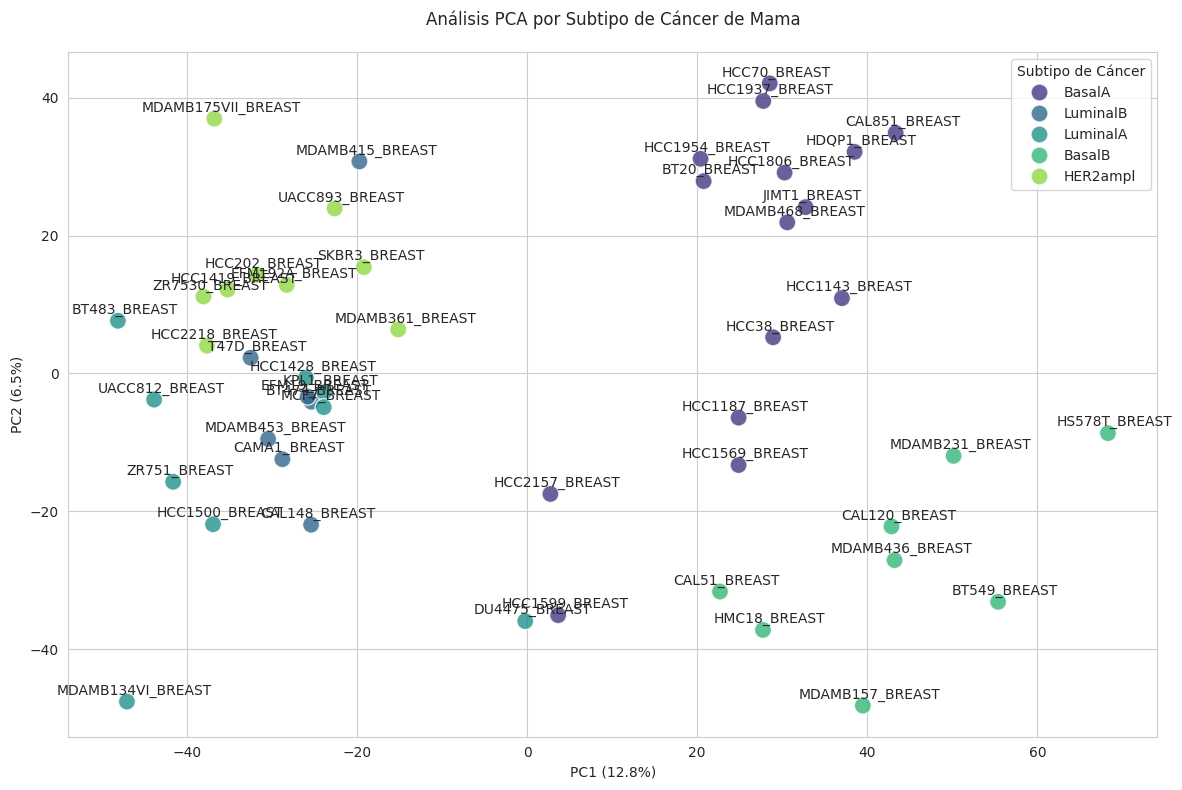

In [23]:
# Utilizamos PCA

# Componentes principales
expression_PCs = pd.DataFrame(PCs, columns=['PC1', 'PC2'])

# usamos subtypes
subtype_labels = []
for sample in expression_transpose.index:  # expression_transpose son tus muestras (filas)
    subtype = subtype_df.loc[subtype_df.index == sample].idxmax(axis=1)[0]
    subtype_labels.append(subtype)

# Asignar los subtipos al DataFrame de PCs
expression_PCs_subtypes = expression_PCs.set_index(pd.Index(subtype_labels))

# Visualizacion
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
scatter = sns.scatterplot(
    x='PC1',
    y='PC2',
    data=expression_PCs_subtypes.reset_index(),  # Reset para usar columnas
    hue='index',  # Usar los subtipos como color
    palette='viridis',  # Paleta de colores
    s=150,  # Tamaño de puntos
    alpha=0.8  # Transparencia
)

# 5. Añadir porcentaje de varianza explicada
plt.xlabel(f'PC1 ({sklearn_pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({sklearn_pca.explained_variance_ratio_[1]*100:.1f}%)')

# 6. Leyenda y título
plt.legend(title='Subtipo de Cáncer')
plt.title('Análisis PCA por Subtipo de Cáncer de Mama', pad=20)

# 7. Añadir etiquetas de muestras (opcional)
for i, sample in enumerate(expression_transpose.index):
    plt.annotate(sample, (PCs[i, 0], PCs[i, 1]), textcoords="offset points", xytext=(5,5), ha='center')

plt.tight_layout()
plt.show()

#Analisis de expresión diferencial

In [24]:
!pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 597.6/597.6 kB 13.9 MB/s eta 0:00:00


In [25]:
import gseapy as gp

In [26]:
# transponemos subtipos
#subtype_df = subtype_df.T
subtypes = ["BasalA", "BasalB", "LuminalA", "LuminalB", "HER2ampl"]

In [27]:
subtype_df

,BasalA,BasalB,LuminalA,LuminalB,HER2ampl
Lineascelulares,,,,,
AU565_BREAST,0,0,0,0,1
BT20_BREAST,1,0,0,0,0
BT474_BREAST,0,0,0,1,0
BT483_BREAST,0,0,1,0,0
BT549_BREAST,0,1,0,0,0
CAL120_BREAST,0,1,0,0,0
CAL148_BREAST,0,0,0,1,0
CAL51_BREAST,0,1,0,0,0
CAL851_BREAST,1,0,0,0,0


In [28]:
# Asegurar que los nombres de muestras coincidan
assert all(sample in filtered_expr.columns for sample in subtype_df.index), "Muestras no coinciden"

In [29]:
filtered_expr.columns

Index(['AU565_BREAST', 'BT20_BREAST', 'BT474_BREAST', 'BT483_BREAST',
       'BT549_BREAST', 'CAL120_BREAST', 'CAL148_BREAST', 'CAL51_BREAST',
       'CAL851_BREAST', 'CAMA1_BREAST', 'DU4475_BREAST', 'EFM192A_BREAST',
       'EFM19_BREAST', 'HCC1143_BREAST', 'HCC1187_BREAST', 'HCC1419_BREAST',
       'HCC1428_BREAST', 'HCC1500_BREAST', 'HCC1569_BREAST', 'HCC1599_BREAST',
       'HCC1806_BREAST', 'HCC1937_BREAST', 'HCC1954_BREAST', 'HCC202_BREAST',
       'HCC2157_BREAST', 'HCC2218_BREAST', 'HCC38_BREAST', 'HCC70_BREAST',
       'HDQP1_BREAST', 'HMC18_BREAST', 'HS578T_BREAST', 'JIMT1_BREAST',
       'KPL1_BREAST', 'MCF7_BREAST', 'MDAMB134VI_BREAST', 'MDAMB157_BREAST',
       'MDAMB175VII_BREAST', 'MDAMB231_BREAST', 'MDAMB361_BREAST',
       'MDAMB415_BREAST', 'MDAMB436_BREAST', 'MDAMB453_BREAST',
       'MDAMB468_BREAST', 'SKBR3_BREAST', 'T47D_BREAST', 'UACC812_BREAST',
       'UACC893_BREAST', 'ZR751_BREAST', 'ZR7530_BREAST'],
      dtype='object')

In [30]:
subtype_df.index

Index(['AU565_BREAST', 'BT20_BREAST', 'BT474_BREAST', 'BT483_BREAST',
       'BT549_BREAST', 'CAL120_BREAST', 'CAL148_BREAST', 'CAL51_BREAST',
       'CAL851_BREAST', 'CAMA1_BREAST', 'DU4475_BREAST', 'EFM19_BREAST',
       'EFM192A_BREAST', 'HCC1143_BREAST', 'HCC1187_BREAST', 'HCC1419_BREAST',
       'HCC1428_BREAST', 'HCC1500_BREAST', 'HCC1569_BREAST', 'HCC1599_BREAST',
       'HCC1806_BREAST', 'HCC1937_BREAST', 'HCC1954_BREAST', 'HCC202_BREAST',
       'HCC2157_BREAST', 'HCC2218_BREAST', 'HCC38_BREAST', 'HCC70_BREAST',
       'HDQP1_BREAST', 'HMC18_BREAST', 'HS578T_BREAST', 'JIMT1_BREAST',
       'KPL1_BREAST', 'MCF7_BREAST', 'MDAMB134VI_BREAST', 'MDAMB157_BREAST',
       'MDAMB175VII_BREAST', 'MDAMB231_BREAST', 'MDAMB361_BREAST',
       'MDAMB415_BREAST', 'MDAMB436_BREAST', 'MDAMB453_BREAST', 'SKBR3_BREAST',
       'T47D_BREAST', 'UACC812_BREAST', 'UACC893_BREAST', 'ZR751_BREAST',
       'ZR7530_BREAST', 'MDAMB468_BREAST'],
      dtype='object', name='Lineascelulares')

In [31]:
# Aqui le pregunte a deepseek como adaptar lo visto en clase para poder
# compararr todos contra todos porque no hay control y treatment explicitos
def calculate_degs(expression_data, subtype_samples, other_samples, pval_threshold=0.05, log2fc_threshold=1):
    """
    Calcula DEGs entre un subtipo y el resto.

    Args:
        expression_data: DataFrame de expresión (genes × muestras).
        subtype_samples: Lista de muestras del subtipo de interés.
        other_samples: Lista de muestras de otros subtipos.

    Returns:
        DataFrame con log2FC, p-valores y significancia.
    """
    # Medias de expresión
    mean_subtype = expression_data[subtype_samples].mean(axis=1)
    mean_other = expression_data[other_samples].mean(axis=1)

    # DataFrame de resultados
    degs = pd.DataFrame({
        'Subtype_Mean': mean_subtype,
        'Other_Mean': mean_other,
        'log2FC': np.log2(mean_subtype / mean_other)
    })

    # Test t (asumiendo varianzas desiguales)
    t_stats, p_values = stats.ttest_ind(
        expression_data[subtype_samples],
        expression_data[other_samples],
        axis=1,
        equal_var=False
    )

    degs['p_value'] = p_values
    degs['p_adj'] = stats.false_discovery_control(p_values)  # Corrección FDR
    degs['significant'] = (degs['p_adj'] < pval_threshold) & (abs(degs['log2FC']) > log2fc_threshold)

    return degs.sort_values('p_adj')

In [32]:
degs_results = {}
subtypes = ['BasalA', 'BasalB', 'LuminalA', 'LuminalB', 'HER2ampl']

for subtype in subtypes:
    # Muestras del subtipo actual
    subtype_samples = subtype_df[subtype_df[subtype] == 1].index
    # Muestras de otros subtipos
    other_samples = subtype_df[subtype_df[subtype] == 0].index

    # Calcular DEGs
    degs = calculate_degs(filtered_expr, subtype_samples, other_samples)
    degs_results[subtype] = degs

    print(f"{subtype}: {degs['significant'].sum()} DEGs significativos")

BasalA: 151 DEGs significativos
BasalB: 440 DEGs significativos
LuminalA: 237 DEGs significativos
LuminalB: 215 DEGs significativos
HER2ampl: 278 DEGs significativos


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [33]:
degs_results['BasalA'].head()

,Subtype_Mean,Other_Mean,log2FC,p_value,p_adj,significant
gene_name,,,,,,
CA12,0.562000,84.881765,-7.238741,1.132356e-07,0.000109,True
MICALL1,36.580000,13.949706,1.390820,6.301616e-08,0.000109,True
SERF2,601.215333,1193.645882,-0.989421,1.090638e-07,0.000109,False
MLPH,32.116667,243.776471,-2.924165,7.591806e-08,0.000109,True
ATP5MC2,234.755333,481.841176,-1.037400,3.564304e-08,0.000109,True


In [34]:
degs_results['BasalB'].head()


,Subtype_Mean,Other_Mean,log2FC,p_value,p_adj,significant
gene_name,,,,,,
GRHL2,0.14500,35.140488,-7.920938,2.472805e-18,1.434227e-14,True
CRB3,1.41250,30.623902,-4.438335,1.904710e-16,5.523659e-13,True
RAB17,0.78375,29.529268,-5.235608,5.325802e-16,1.029655e-12,True
RAB25,0.31750,178.070732,-9.131478,1.262756e-15,1.830996e-12,True
ESRP1,0.22125,79.958780,-8.497435,4.099759e-15,4.755720e-12,True


In [35]:
degs_results['LuminalA'].head()


,Subtype_Mean,Other_Mean,log2FC,p_value,p_adj,significant
gene_name,,,,,,
RBM7,7.197778,19.82925,-1.462007,9.087753e-07,0.000878,True
IRF1,7.500000,30.81625,-2.038729,8.527316e-07,0.000878,True
TRIP10,17.591111,47.55275,-1.434682,7.031584e-07,0.000878,True
REXO2,38.566667,96.49300,-1.323070,8.250825e-07,0.000878,True
RDH10,6.356667,29.50950,-2.214837,7.463736e-07,0.000878,True


In [36]:
degs_results['LuminalB'].head()


,Subtype_Mean,Other_Mean,log2FC,p_value,p_adj,significant
gene_name,,,,,,
PIP4P2,0.742857,8.989048,-3.597012,3.272256e-09,0.000019,True
ADCY7,0.791429,8.881429,-3.488261,2.521504e-07,0.000572,True
QKI,8.970000,35.646429,-1.990578,2.960219e-07,0.000572,True
PLEKHB2,30.678571,58.441667,-0.929766,9.832004e-07,0.000648,False
CCDC82,1.151429,18.939048,-4.039867,1.026953e-06,0.000648,True


In [37]:
degs_results['HER2ampl'].head()

,Subtype_Mean,Other_Mean,log2FC,p_value,p_adj,significant
gene_name,,,,,,
BOD1,31.821,62.431282,-0.972290,3.042344e-08,0.000112,False
MAP4K4,7.104,52.958974,-2.898172,3.853038e-08,0.000112,True
CDC27,16.535,37.229744,-1.170933,8.704488e-08,0.000168,True
KIF18A,5.521,12.636667,-1.194614,1.033615e-06,0.000929,True
BIRC2,13.276,31.554103,-1.249007,1.281315e-06,0.000929,True


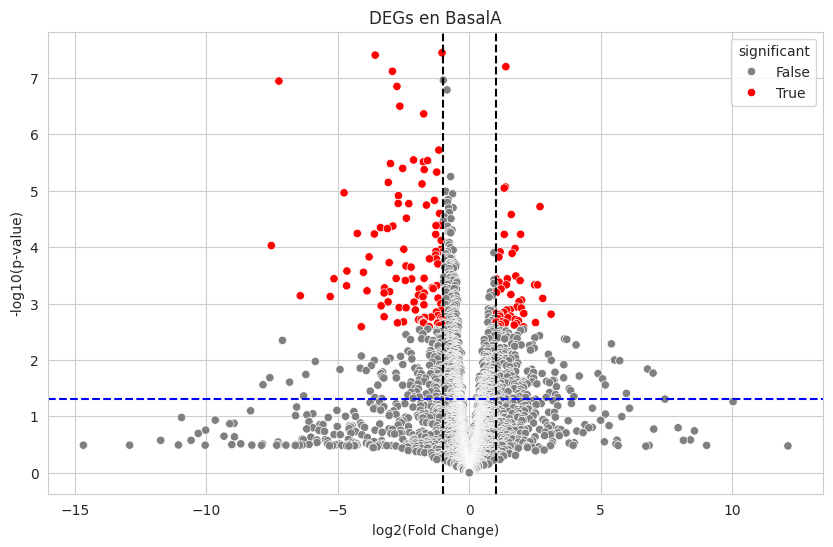

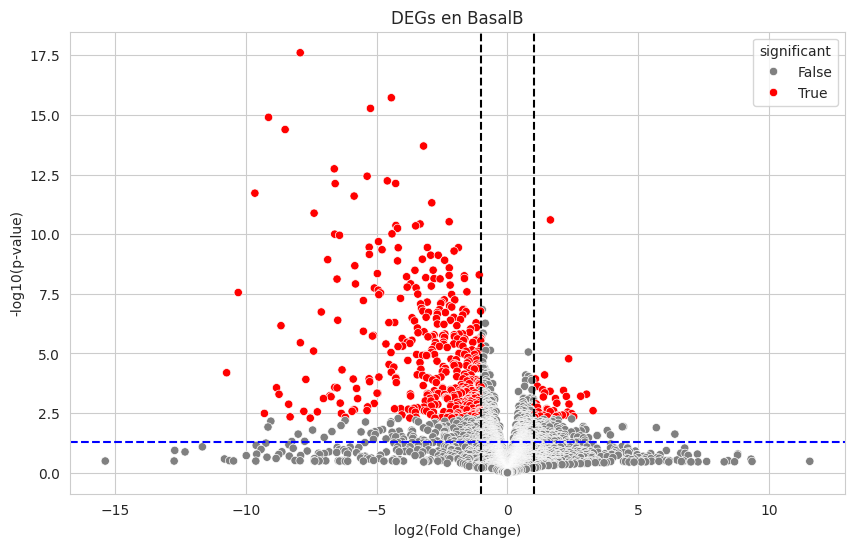

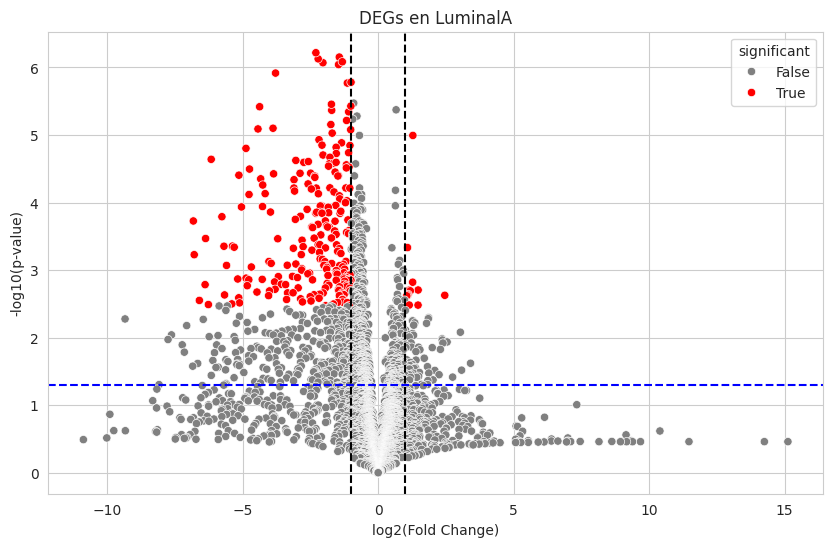

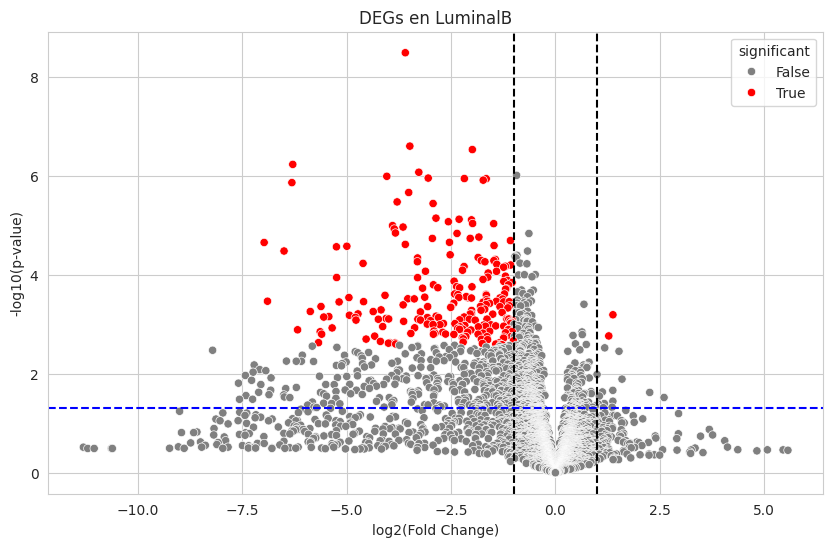

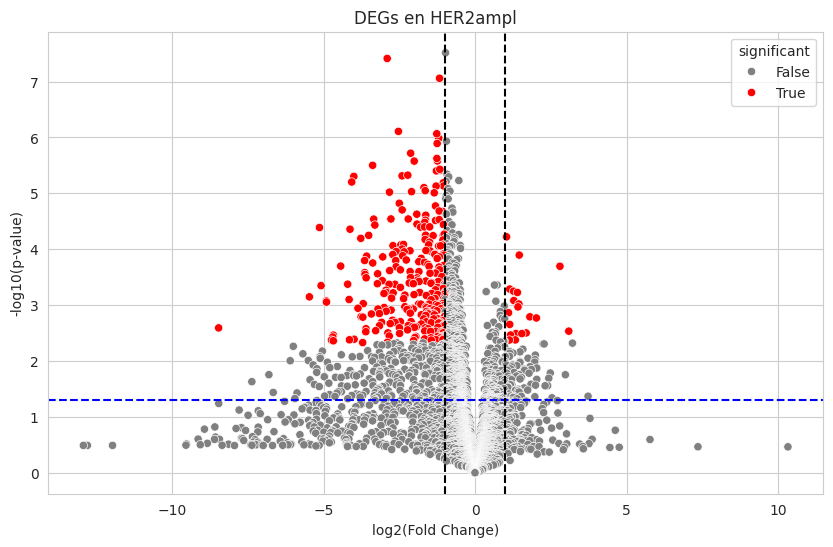

In [38]:
def plot_volcano(deg_df, subtype):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x='log2FC',
        y=-np.log10(deg_df['p_value']),
        hue=deg_df['significant'],
        palette={True: 'red', False: 'gray'},
        data=deg_df
    )
    plt.axhline(-np.log10(0.05), linestyle='--', color='blue')
    plt.axvline(-1, linestyle='--', color='black')
    plt.axvline(1, linestyle='--', color='black')
    plt.title(f'DEGs en {subtype}')
    plt.xlabel('log2(Fold Change)')
    plt.ylabel('-log10(p-value)')
    plt.show()

plot_volcano(degs_results['BasalA'], 'BasalA')
plot_volcano(degs_results['BasalB'], 'BasalB')
plot_volcano(degs_results['LuminalA'], 'LuminalA')
plot_volcano(degs_results['LuminalB'], 'LuminalB')
plot_volcano(degs_results['HER2ampl'], 'HER2ampl')

In [39]:
databases = [
    'KEGG_2021_Human',
    'GO_Biological_Process_2021',
    'Reactome_2022'
]

In [40]:
for subtype in degs_results.keys():
    degs = degs_results[subtype][degs_results[subtype]['significant']].index.tolist()
    if len(degs) > 0:  # Solo si hay DEGs
        enr = gp.enrichr(gene_list=degs, gene_sets=databases, organism='human')
        enr.results.to_csv(f'enrichment_{subtype}.csv', index=False)
        print(f"\n=== {subtype} ===")
        print(enr.results[['Term', 'Adjusted P-value']].head(3))


=== BasalA ===
                                     Term  Adjusted P-value
0                  Dilated cardiomyopathy          0.091851
1  Adrenergic signaling in cardiomyocytes          0.091851
2              Estrogen signaling pathway          0.137204

=== BasalB ===
                      Term  Adjusted P-value
0           Tight junction           0.09604
1       Insulin resistance           0.71179
2  Proteoglycans in cancer           0.71179

=== LuminalA ===
                       Term  Adjusted P-value
0   Proteoglycans in cancer          0.000036
1            Focal adhesion          0.000564
2  ECM-receptor interaction          0.000704

=== LuminalB ===
                       Term  Adjusted P-value
0            Focal adhesion          0.000065
1   Proteoglycans in cancer          0.000268
2  ECM-receptor interaction          0.000364

=== HER2ampl ===
                 Term  Adjusted P-value
0  Pathways in cancer          0.000029
1      Focal adhesion          0.000069
2   Pa

In [45]:
# Ahora, encontraremos clusters para cada subtipo de genes

# BasalA
basalA_degs = degs_results['BasalA'][degs_results['BasalA']['significant']].index
expression_basalA = filtered_expr.loc[basalA_degs]  # Datos de expresión para DEGs de BasalA

# Estandarizar datos (crucial para k-means)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(expression_basalA)

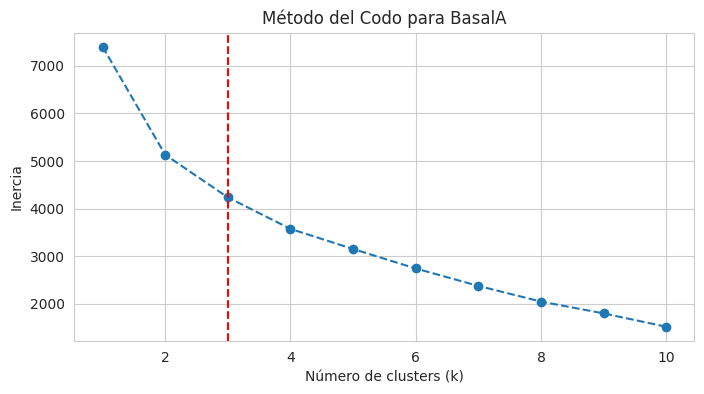

In [47]:
inertia = []
k_range = range(1, 11)  # Probamos k de 1 a 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para BasalA')
plt.axvline(x=3, color='r', linestyle='--')  # k=3
plt.show()

In [49]:
k_optimal = 3  # k=3
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
clusters = kmeans.fit_predict(scaled_data)
expression_basalA['Cluster'] = clusters #etiquetas

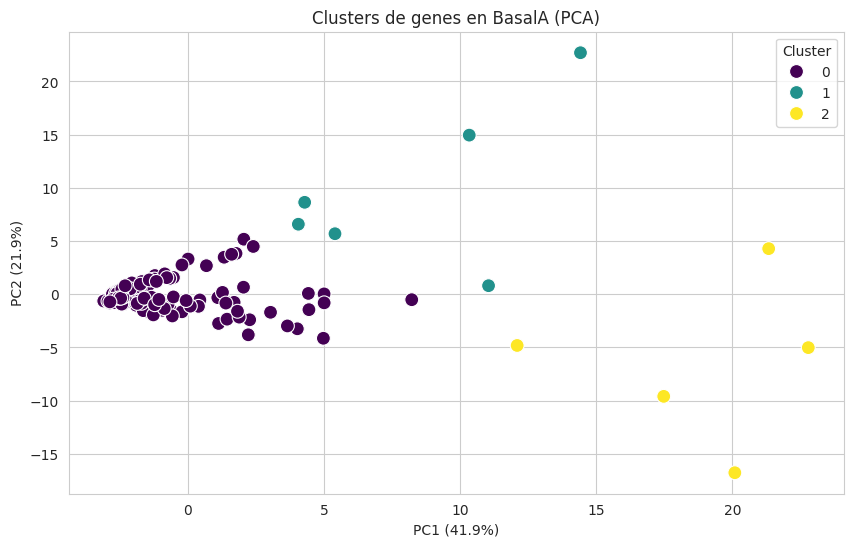

In [53]:
# Reducir dimensionalidad a 2D con PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Crear DataFrame para visualización
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Cluster': clusters
})

# Graficar
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    palette='viridis',
    data=pca_df,
    s=100
)
plt.title('Clusters de genes en BasalA (PCA)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.show()

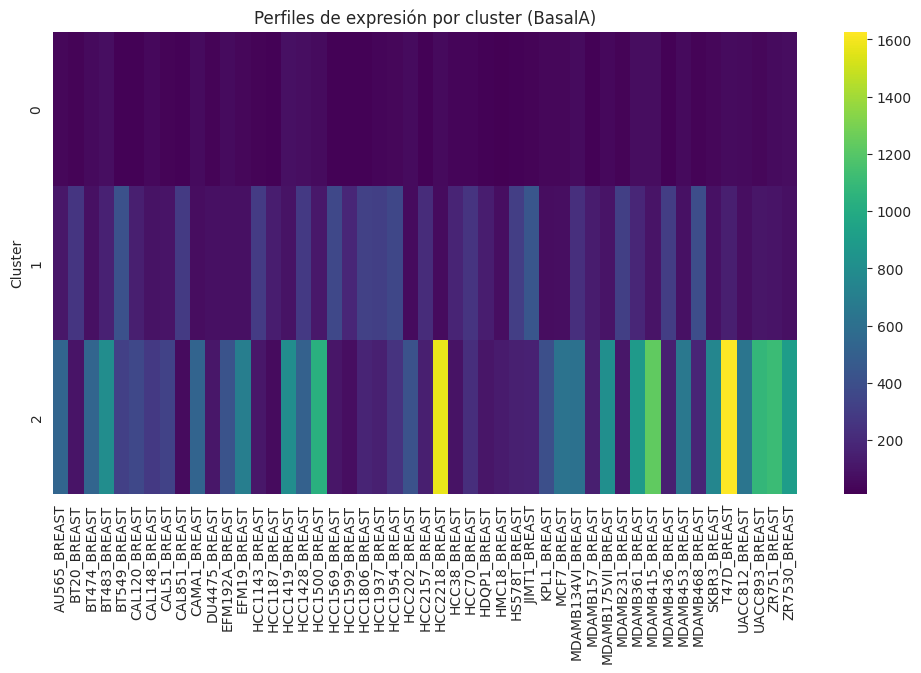

In [51]:
# Calcular la expresión media por cluster
cluster_means = expression_basalA.groupby('Cluster').mean()

# Heatmap de perfiles
plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_means,
    cmap='viridis',
    xticklabels=True,
    yticklabels=True
)
plt.title('Perfiles de expresión por cluster (BasalA)')
plt.show()

In [52]:
for cluster_id in range(k_optimal):
    genes_in_cluster = expression_basalA[expression_basalA['Cluster'] == cluster_id].index.tolist()
    enr = gp.enrichr(
        gene_list=genes_in_cluster,
        gene_sets=['KEGG_2021_Human', 'GO_Biological_Process_2021'],
        organism='human'
    )
    print(f"\n=== Cluster {cluster_id} ===")
    print(enr.results[['Term', 'Adjusted P-value']].head(3))


=== Cluster 0 ===
                                      Term  Adjusted P-value
0                   Dilated cardiomyopathy          0.058920
1   Adrenergic signaling in cardiomyocytes          0.058920
2  Human T-cell leukemia virus 1 infection          0.106574

=== Cluster 1 ===
                         Term  Adjusted P-value
0     Proteoglycans in cancer          0.016790
1    ECM-receptor interaction          0.075143
2  Hematopoietic cell lineage          0.075143

=== Cluster 2 ===
                            Term  Adjusted P-value
0              Parkinson disease          0.015269
1  Amyotrophic lateral sclerosis          0.015269
2              Alzheimer disease          0.015269


In [56]:
# BasalB
basalB_degs = degs_results['BasalB'][degs_results['BasalB']['significant']].index
expression_basalB = filtered_expr.loc[basalB_degs]  # Datos de expresión para DEGs de BasalB

# Estandarizar datos (crucial para k-means)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(expression_basalB)

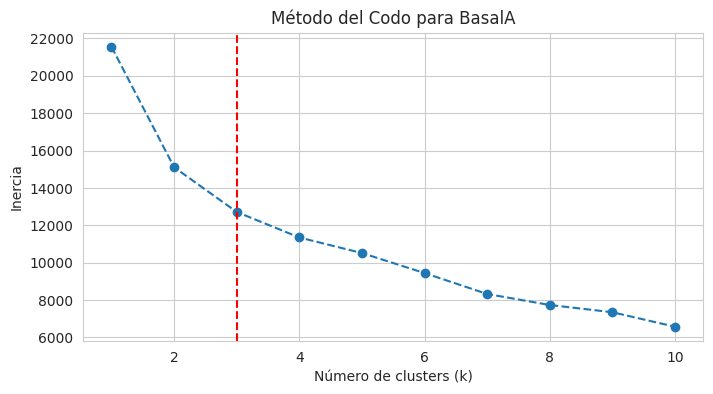

In [57]:
inertia = []
k_range = range(1, 11)  # Probamos k de 1 a 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para BasalA')
plt.axvline(x=3, color='r', linestyle='--')  # k=3
plt.show()

In [60]:
k_optimal = 3  # Ajusta según el método del codo
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Añadir etiquetas de cluster al DataFrame
expression_basalB['Cluster'] = clusters

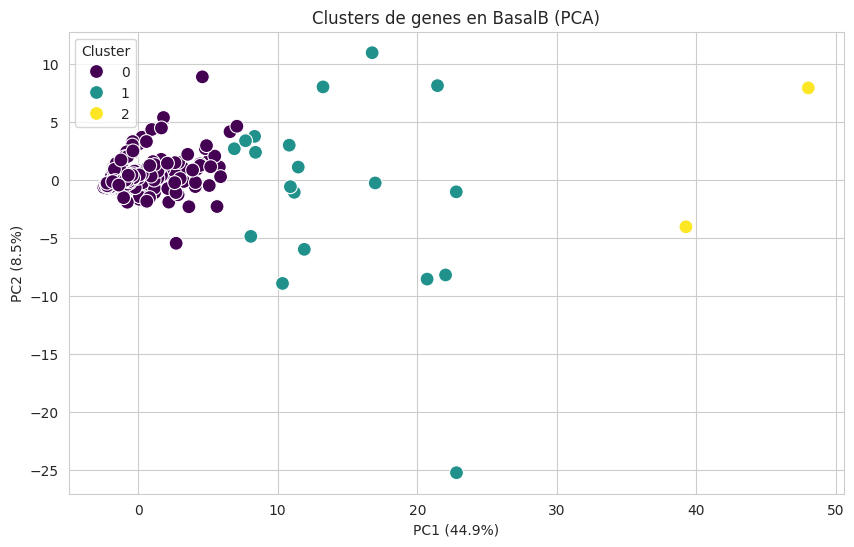

In [62]:
# Reducir dimensionalidad
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Crear DataFrame para visualización
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Cluster': clusters
})

# Graficar
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    palette='viridis',
    data=pca_df,
    s=100
)
plt.title('Clusters de genes en BasalB (PCA)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.show()

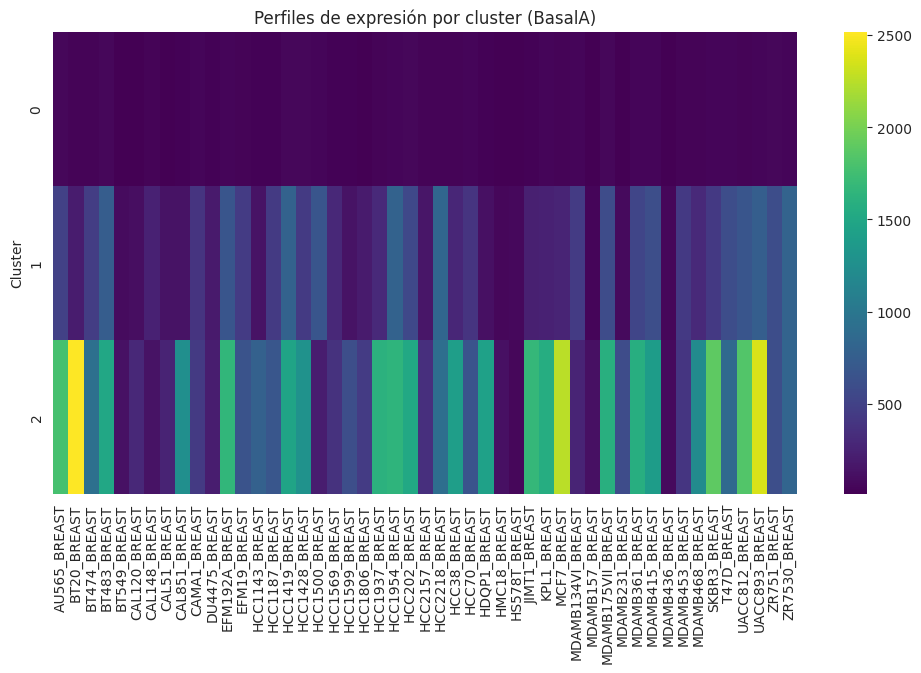

In [64]:
# Calcular la expresión media por cluster
cluster_means = expression_basalB.groupby('Cluster').mean()

# Heatmap de perfiles
plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_means,
    cmap='viridis',
    xticklabels=True,
    yticklabels=True
)
plt.title('Perfiles de expresión por cluster (BasalA)')
plt.show()

In [67]:
for cluster_id in range(k_optimal):
    genes_in_cluster = expression_basalB[expression_basalB['Cluster'] == cluster_id].index.tolist()
    enr = gp.enrichr(
        gene_list=genes_in_cluster,
        gene_sets=['KEGG_2021_Human', 'GO_Biological_Process_2021'],
        organism='human'
    )
    print(f"\n=== Cluster {cluster_id} ===")
    print(enr.results[['Term', 'Adjusted P-value']].head(3))


=== Cluster 0 ===
                           Term  Adjusted P-value
0                Tight junction          0.697885
1            Insulin resistance          0.697885
2  Choline metabolism in cancer          0.697885

=== Cluster 1 ===
                      Term  Adjusted P-value
0           Tight junction          0.172804
1  Proteoglycans in cancer          0.172804
2      Nitrogen metabolism          0.172804

=== Cluster 2 ===
                                                Term  Adjusted P-value
0                    Staphylococcus aureus infection          0.013653
1                         Estrogen signaling pathway          0.013653
2  Golgi to plasma membrane protein transport (GO...          0.011991


In [113]:
#LuminalA
LuminalA_degs = degs_results['LuminalA'][degs_results['LuminalA']['significant']].index
expression_LuminalA = filtered_expr.loc[LuminalA_degs]

# Estandarizar datos (crucial para k-means)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(expression_LuminalA)

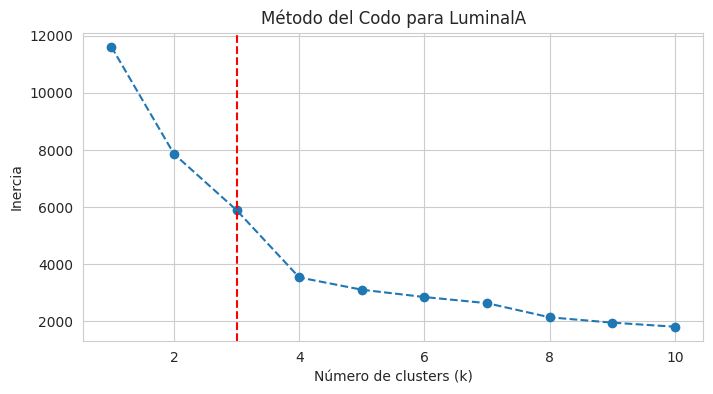

In [114]:
inertia = []
k_range = range(1, 11)  # Probamos k de 1 a 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para LuminalA')
plt.axvline(x=3, color='r', linestyle='--')  # Se intento con k=4 y no funciono en el analisis
plt.show()

In [115]:
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Añadir etiquetas de cluster al DataFrame
expression_LuminalA['Cluster'] = clusters

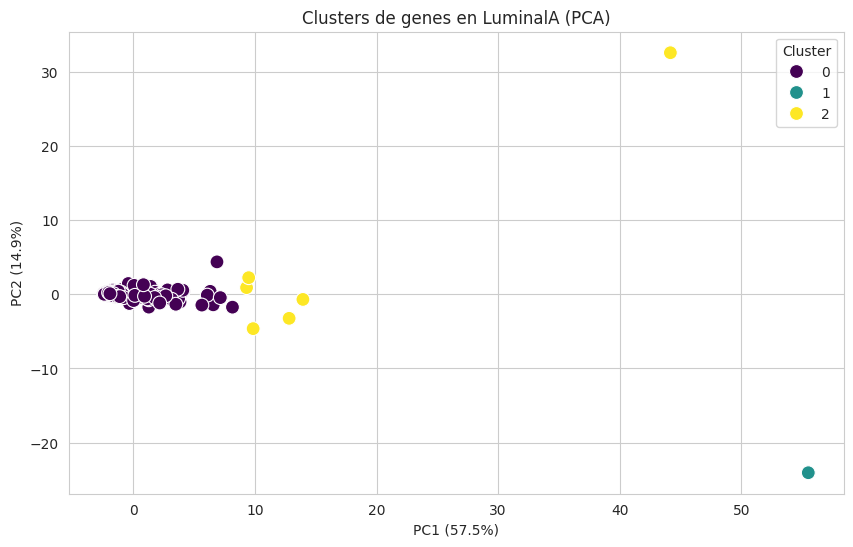

In [116]:
# Reducir dimensionalidad a 2D con PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Crear DataFrame para visualización
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Cluster': clusters
})

# Graficar
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    palette='viridis',
    data=pca_df,
    s=100
)
plt.title('Clusters de genes en LuminalA (PCA)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.show()

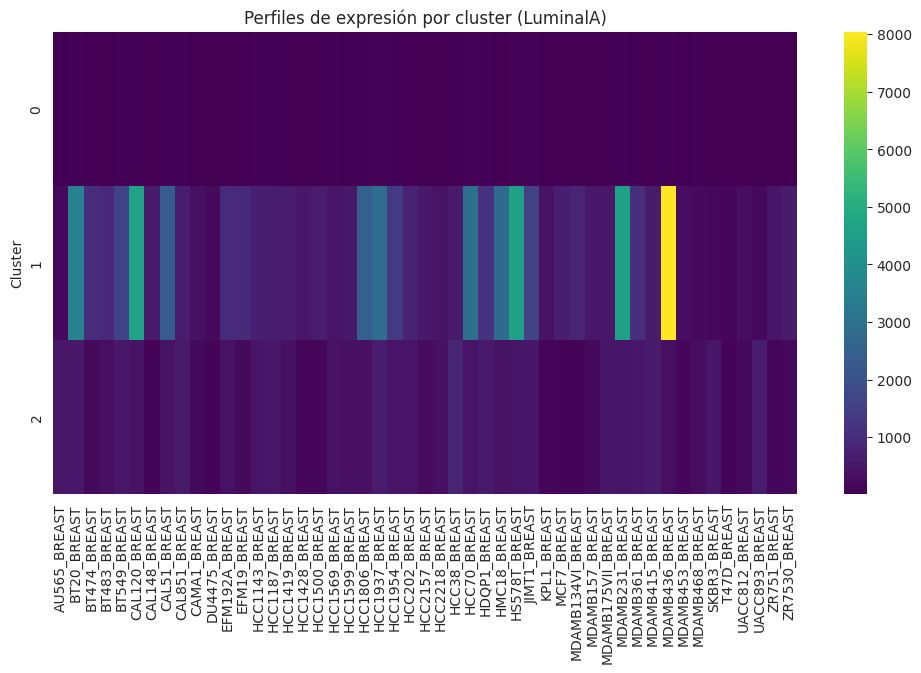

In [117]:
# Calcular la expresión media por cluster
cluster_means = expression_LuminalA.groupby('Cluster').mean()

# Heatmap de perfiles
plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_means,
    cmap='viridis',
    xticklabels=True,
    yticklabels=True
)
plt.title('Perfiles de expresión por cluster (LuminalA)')
plt.show()

In [101]:
for cluster_id in range(k_optimal):
    genes_in_cluster = expression_LuminalA[expression_LuminalA['Cluster'] == cluster_id].index.tolist()
    enr = gp.enrichr(
        gene_list=genes_in_cluster,
        gene_sets=['KEGG_2021_Human', 'GO_Biological_Process_2021'],
        organism='human'
    )
    print(f"\n=== Cluster {cluster_id} ===")
    print(enr.results[['Term', 'Adjusted P-value']].head(3))


=== Cluster 0 ===
                       Term  Adjusted P-value
0   Proteoglycans in cancer          0.000161
1            Focal adhesion          0.002318
2  ECM-receptor interaction          0.004871

=== Cluster 1 ===
                 Term  Adjusted P-value
0         Ferroptosis           0.00450
1  Mineral absorption           0.00450
2         Necroptosis           0.00795

=== Cluster 2 ===
                     Term  Adjusted P-value
0  Rap1 signaling pathway          0.070435
1   Propanoate metabolism          0.078089
2     Pyruvate metabolism          0.078089


In [118]:
#LuminalB
LuminalB_degs = degs_results['LuminalB'][degs_results['LuminalB']['significant']].index
expression_LuminalB = filtered_expr.loc[LuminalB_degs]

# Estandarizar datos (crucial para k-means)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(expression_LuminalB)

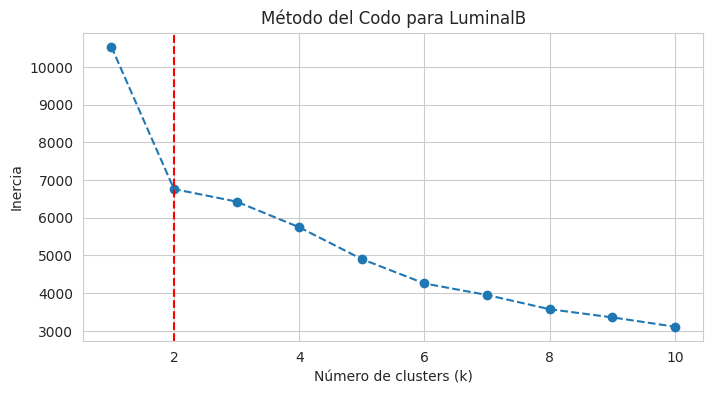

In [119]:
inertia = []
k_range = range(1, 11)  # Probamos k de 1 a 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para LuminalB')
plt.axvline(x=2, color='r', linestyle='--')
plt.show()

In [120]:
k_optimal = 2
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Añadir etiquetas de cluster al DataFrame
expression_LuminalB['Cluster'] = clusters

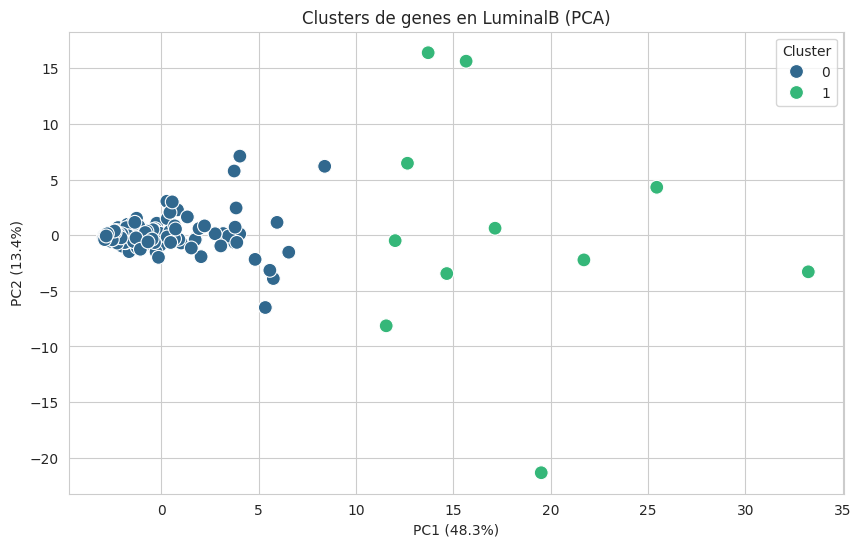

In [122]:
# Reducir dimensionalidad a 2D con PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Crear DataFrame para visualización
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Cluster': clusters
})

# Graficar
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    palette='viridis',
    data=pca_df,
    s=100
)
plt.title('Clusters de genes en LuminalB (PCA)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.show()

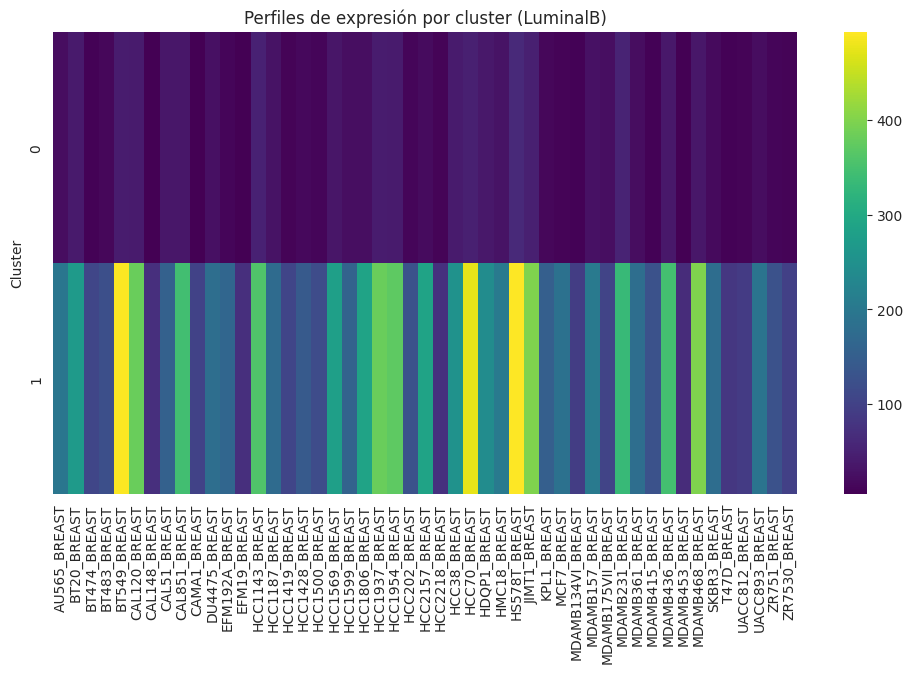

In [132]:
# Calcular la expresión media por cluster
cluster_means = expression_LuminalB.groupby('Cluster').mean()

# Heatmap de perfiles
plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_means,
    cmap='viridis',
    xticklabels=True,
    yticklabels=True
)
plt.title('Perfiles de expresión por cluster (LuminalB)')
plt.show()

In [124]:
for cluster_id in range(k_optimal):
    genes_in_cluster = expression_LuminalB[expression_LuminalB['Cluster'] == cluster_id].index.tolist()
    enr = gp.enrichr(
        gene_list=genes_in_cluster,
        gene_sets=['KEGG_2021_Human', 'GO_Biological_Process_2021'],
        organism='human'
    )
    print(f"\n=== Cluster {cluster_id} ===")
    print(enr.results[['Term', 'Adjusted P-value']].head(3))


=== Cluster 0 ===
                      Term  Adjusted P-value
0           Focal adhesion          0.001628
1       Pathways in cancer          0.003791
2  Proteoglycans in cancer          0.003799

=== Cluster 1 ===
                               Term  Adjusted P-value
0                    Tight junction          0.000057
1                       Shigellosis          0.000127
2  Regulation of actin cytoskeleton          0.002437


In [125]:
#HER2ampl
HER2ampl_degs = degs_results['HER2ampl'][degs_results['HER2ampl']['significant']].index
expression_HER2ampl = filtered_expr.loc[HER2ampl_degs]

# Estandarizar datos (crucial para k-means)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(expression_HER2ampl)

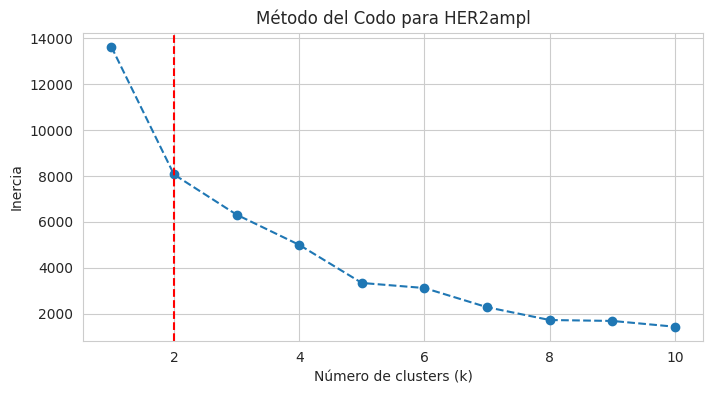

In [126]:
inertia = []
k_range = range(1, 11)  # Probamos k de 1 a 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para HER2ampl')
plt.axvline(x=2, color='r', linestyle='--')
plt.show()

In [127]:
k_optimal = 2
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Añadir etiquetas de cluster al DataFrame
expression_HER2ampl['Cluster'] = clusters

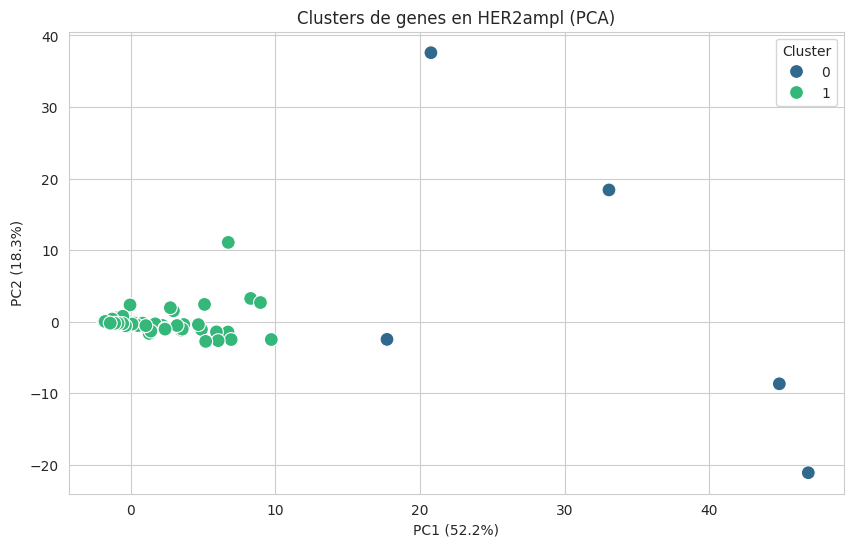

In [129]:
# Reducir dimensionalidad a 2D con PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Crear DataFrame para visualización
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Cluster': clusters
})

# Graficar
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    palette='viridis',
    data=pca_df,
    s=100
)
plt.title('Clusters de genes en HER2ampl (PCA)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.show()

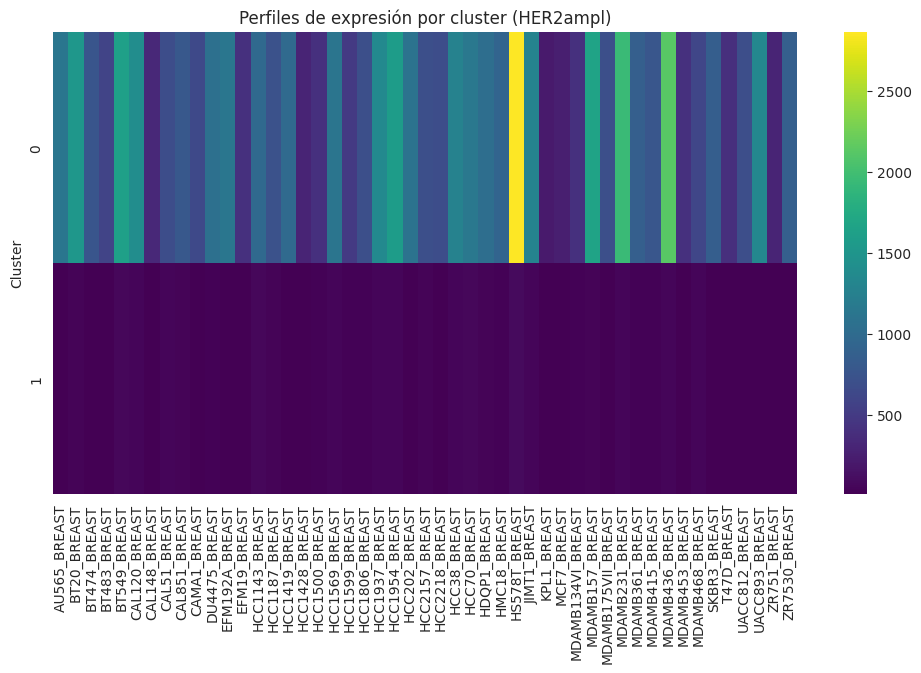

In [130]:
# Calcular la expresión media por cluster
cluster_means = expression_HER2ampl.groupby('Cluster').mean()

# Heatmap de perfiles
plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_means,
    cmap='viridis',
    xticklabels=True,
    yticklabels=True
)
plt.title('Perfiles de expresión por cluster (HER2ampl)')
plt.show()

In [133]:
for cluster_id in range(k_optimal):
    genes_in_cluster = expression_HER2ampl[expression_HER2ampl['Cluster'] == cluster_id].index.tolist()
    enr = gp.enrichr(
        gene_list=genes_in_cluster,
        gene_sets=['KEGG_2021_Human', 'GO_Biological_Process_2021'],
        organism='human'
    )
    print(f"\n=== Cluster {cluster_id} ===")
    print(enr.results[['Term', 'Adjusted P-value']].head(3))


=== Cluster 0 ===
                     Term  Adjusted P-value
0  MAPK signaling pathway          0.025541
1     MicroRNAs in cancer          0.025541
2          Bladder cancer          0.041487

=== Cluster 1 ===
                                      Term  Adjusted P-value
0                       Pathways in cancer          0.000078
1  Human T-cell leukemia virus 1 infection          0.000245
2                            Toxoplasmosis          0.000249
